### **Decision Tree - Diabetes**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pritsheta/diabetes-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'diabetes-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-dataset


About Dataset
Diabetes

This is Diabetes dataset. you can use this data set for prediction. in this dataset have many parameters such as Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigree, Age, Outcome.


In [21]:
import pandas as pd
import os

files = os.listdir(path)

# csv dosyasını bul
csv_file = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [22]:
print(df.shape)
print(df.info())
print(df["Outcome"].value_counts())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Outcome
0    500
1    268
Name: count, dtype: int64


In [23]:
## x ve y ayir

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(537, 8) (231, 8)


In [28]:
## Modeli olustur

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained")

Model trained


In [29]:
# Tahmin + Accuracy + Report
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))

Accuracy: 0.7272727272727273

              precision    recall  f1-score   support

           0       0.75      0.86      0.80       150
           1       0.65      0.48      0.55        81

    accuracy                           0.73       231
   macro avg       0.70      0.67      0.68       231
weighted avg       0.72      0.73      0.72       231



*  Model genel olarak fena değil ama çok güçlü de değil.Model “0” sınıfını iyi tanımış f1 score nispeten iyi ancak 1 sinifini taniyamamis.Veri dengesiz olabilir (0 daha fazla olabilir) *

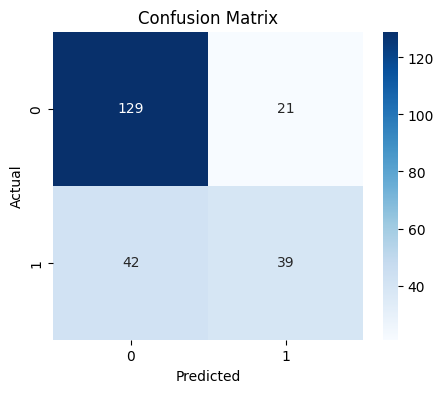

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Modelin confusion matrix sonuçlarına göre:

* True Negative (TN): 129 → Gerçek negatiflerin büyük kısmı doğru tahmin edilmiştir. Model “0” sınıfını iyi öğrenmiştir.
* False Positive (FP): 21 → Gerçekte negatif olan bazı örnekler yanlışlıkla pozitif tahmin edilmiştir.
* False Negative (FN): 42 → Gerçekte pozitif olan önemli bir kısım örnek negatif olarak tahmin edilmiştir. Bu hata oranı yüksektir.
* True Positive (TP): 39 → Pozitif sınıfın bir kısmı doğru şekilde tahmin edilmiştir.



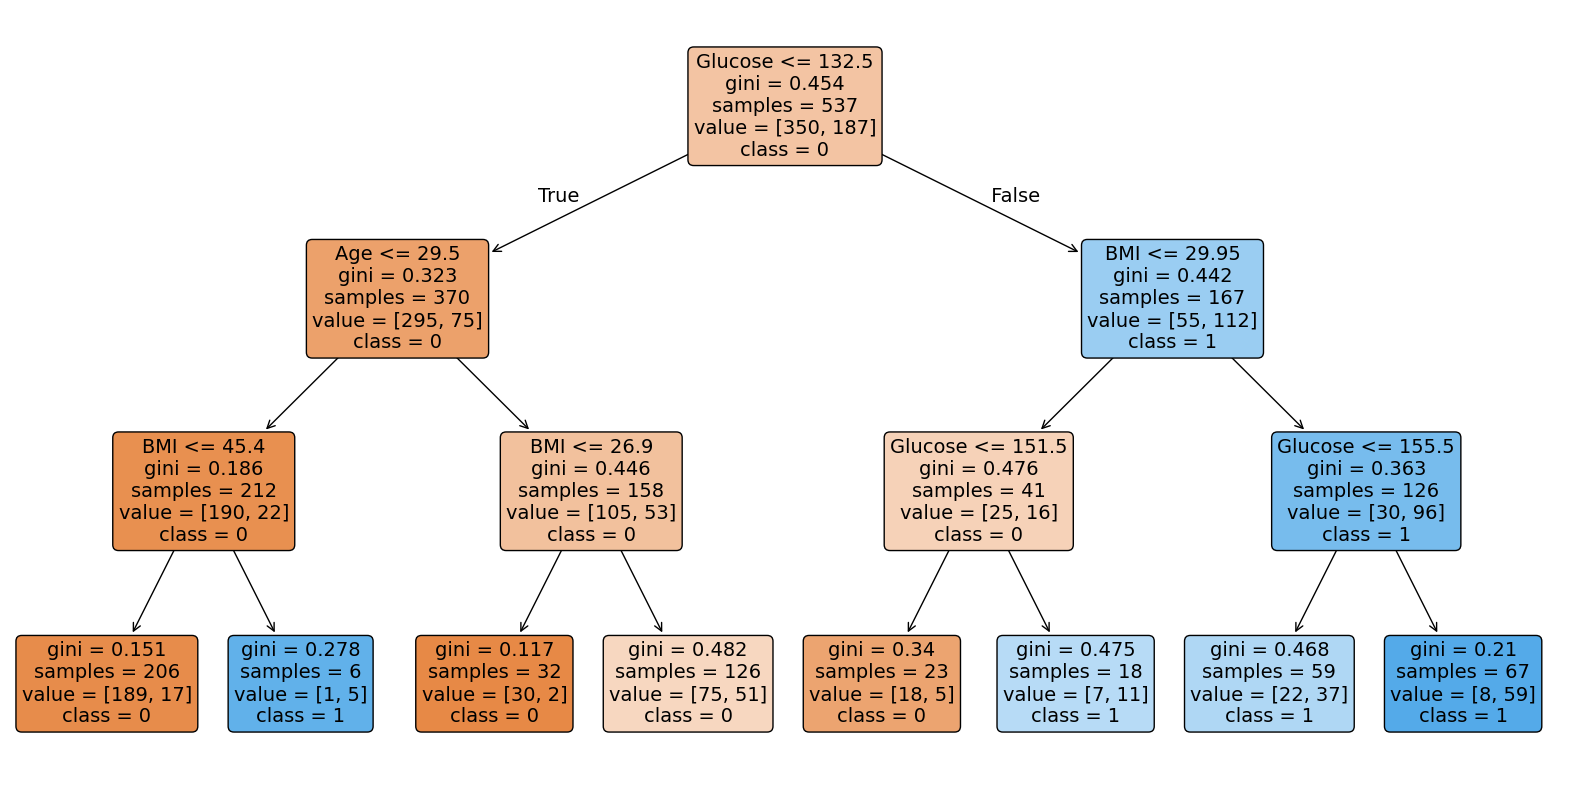

In [31]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True
)

plt.show()

Karar ağacı modeli incelendiğinde en önemli değişkenin Glucose olduğu görülmektedir. Model ilk ayrımı glukoz değerine göre yapmış ve bu değişkenin sınıflandırma üzerinde en etkili özellik olduğu anlaşılmıştır. Daha sonraki aşamalarda ise Age ve BMI değişkenleri karar verme sürecinde kullanılmıştır.

Ağaç yapısında bulunan gini değeri, düğümlerdeki veri saflığını göstermektedir. Gini değerinin 0’a yakın olması o düğümdeki verilerin büyük çoğunluğunun aynı sınıfa ait olduğunu ve modelin daha net karar verdiğini ifade etmektedir. Gini değerinin yüksek olması ise sınıfların daha karışık olduğunu göstermektedir. Bu modelde bazı yaprak düğümlerde düşük gini değerleri elde edilmesi modelin belirli kurallarda başarılı ayrım yaptığını göstermektedir.

Modelin derinliği sınırlandırılarak ağacın fazla büyümesi engellenmiştir. Böylece aşırı dallanma (overfitting) problemi azaltılmıştır. Overfitting durumunda model eğitim verisini ezberlemeye başlar ve yeni veriler üzerinde başarısı düşebilir. Ağacın sadeleştirilmesi sayesinde model daha anlaşılır hale gelmiş ve genelleme performansının artırılması amaçlanmıştır. Genel olarak model, veriler arasındaki temel ilişkileri başarılı şekilde öğrenmiş ve yorumlanabilir bir yapı oluşturmuştur.

In [34]:
from sklearn.tree import export_text

tree_rules = export_text(
    model,
    feature_names=list(X.columns),
    spacing=3
)

print(tree_rules)

|--- Glucose <= 132.50
|   |--- Age <= 29.50
|   |   |--- BMI <= 45.40
|   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  29.50
|   |   |--- BMI <= 26.90
|   |   |   |--- class: 0
|   |   |--- BMI >  26.90
|   |   |   |--- class: 0
|--- Glucose >  132.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 151.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- class: 1
|   |--- BMI >  29.95
|   |   |--- Glucose <= 155.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  155.50
|   |   |   |--- class: 1



Karar ağacı incelendiğinde en önemli değişkenin Glucose olduğu görülmektedir. Düşük glukoz değerlerinde model çoğunlukla Class 0, yüksek glukoz değerlerinde ise Class 1 tahmini yapmıştır. BMI ve Age değişkenleri de karar sürecinde etkili olmuştur. Ağacın sade tutulması sayesinde model daha anlaşılır hale gelmiş ve overfitting riski azaltılmıştır.


En Önemli 10 Özellik:
                    feature  importance
1                   Glucose    0.651299
5                       BMI    0.238739
7                       Age    0.109962
0               Pregnancies    0.000000
3             SkinThickness    0.000000
2             BloodPressure    0.000000
4                   Insulin    0.000000
6  DiabetesPedigreeFunction    0.000000


/tmp/ipykernel_12182/2263195374.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10),


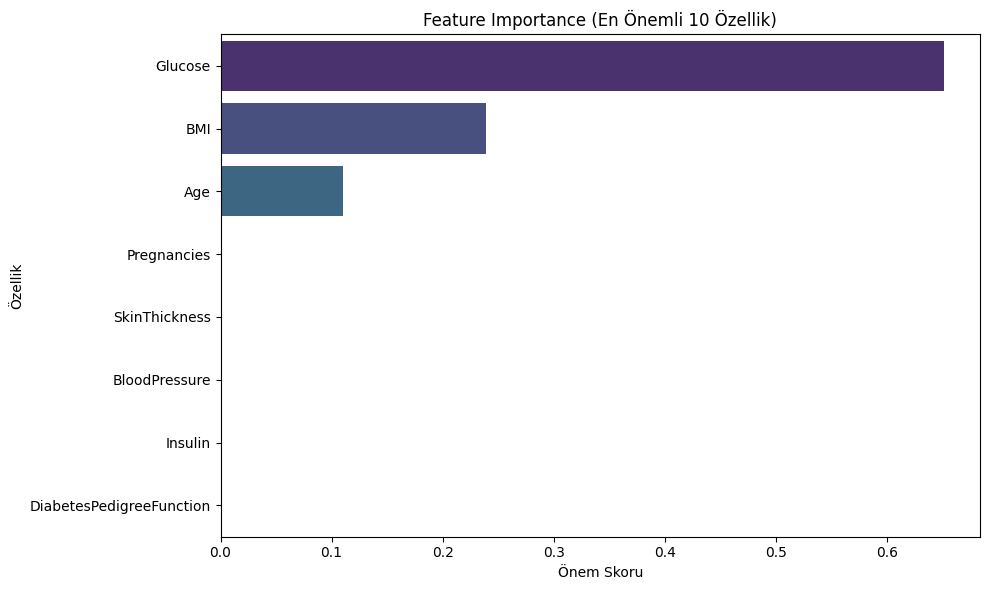

In [35]:
# Özellik önem sıralaması (Feature Importance)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("En Önemli 10 Özellik:")
print(feature_importance.head(10))

# Görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10),
            x='importance', y='feature',
            palette='viridis')
plt.title('Feature Importance (En Önemli 10 Özellik)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

In [36]:
# Modelin overfitting kontrolü için eğitim ve test doğruluklarını karşılaştır
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Eğitim Doğruluğu: {train_accuracy:.4f}")
print(f"Test Doğruluğu:   {test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.1:
    print("⚠️  Model overfitting yapıyor olabilir (eğitim-test farkı > %10).")
elif train_accuracy - test_accuracy > 0.05:
    print("⚠️  Hafif overfitting olabilir.")
else:
    print("✓  Model genellemesi iyi (overfitting yok).")

Eğitim Doğruluğu: 0.7896
Test Doğruluğu:   0.7273
⚠️  Hafif overfitting olabilir.


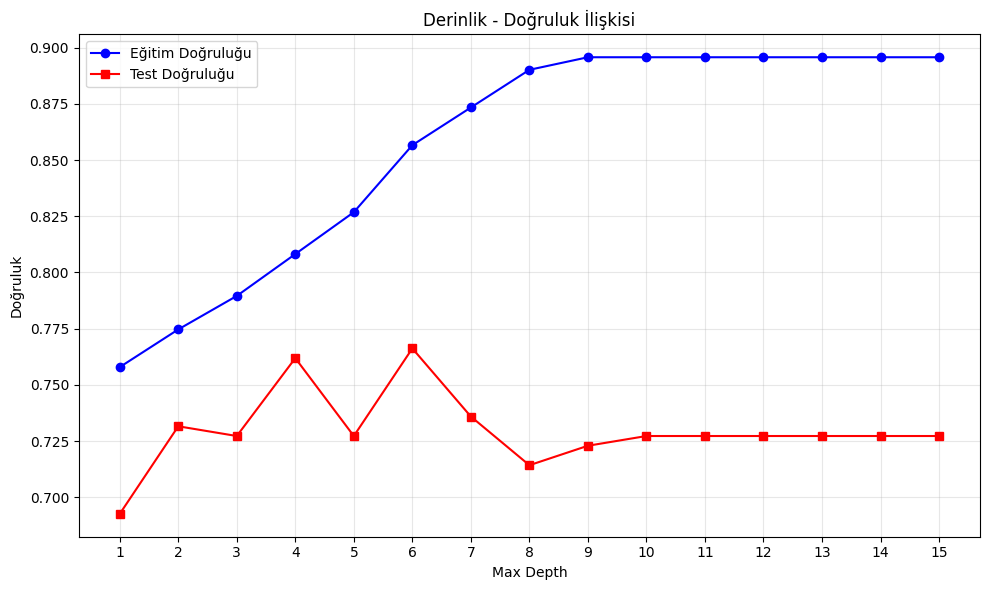

In [37]:
# Farklı max_depth değerleri ile model karşılaştırması
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        criterion='gini',
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Görselleştir
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-o', label='Eğitim Doğruluğu')
plt.plot(depths, test_scores, 'r-s', label='Test Doğruluğu')
plt.xlabel('Max Depth')
plt.ylabel('Doğruluk')
plt.title('Derinlik - Doğruluk İlişkisi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

Decision Tree algoritması veri seti üzerinde uygulanmıştır.
Veri eğitim ve test olarak ayrılmıştır.
Model Gini impurity kriteri kullanılarak oluşturulmuştur.
Karar ağacında en önemli değişkenlerin Glucose, BMI ve Age olduğu gözlemlenmiştir.
Modelin overfitting durumu kontrol edilmiş ve farklı max_depth değerleri karşılaştırılarak en uygun derinlik seçilmiştir.

# Random Forest ve Decision Tree Karşılaştırması

Aynı diyabet veri seti üzerinde hem Decision Tree hem de Random Forest algoritmaları uygulanmıştır. Sonuçlar karşılaştırıldığında Random Forest modelinin genel olarak daha başarılı performans gösterdiği görülmüştür.

## 📊 Accuracy Karşılaştırması

- Decision Tree Accuracy: 0.7273
- Random Forest Accuracy: 0.7532
- Optimize edilmiş Random Forest Accuracy: 0.7597

Random Forest modeli daha yüksek doğruluk oranı elde etmiştir.

---

## 📋 Precision / Recall / F1-Score Karşılaştırması

### Decision Tree

| Sınıf | Precision | Recall | F1-Score |
|---|---|---|---|
| 0 | 0.75 | 0.86 | 0.80 |
| 1 | 0.65 | 0.48 | 0.55 |

### Random Forest

| Sınıf | Precision | Recall | F1-Score |
|---|---|---|---|
| 0 | 0.79 | 0.85 | 0.82 |
| 1 | 0.67 | 0.57 | 0.62 |

Random Forest modeli özellikle diyabet olan bireyleri temsil eden “1” sınıfında daha iyi sonuç vermiştir. Recall değerinin 0.48’den 0.57’ye yükselmesi modelin diyabet hastalarını daha başarılı tespit ettiğini göstermektedir.

---

## 🌲 Model Yapısı Farkı

- Decision Tree tek bir karar ağacından oluşmaktadır.
- Random Forest ise çok sayıda karar ağacının birleşiminden oluşan ensemble bir yöntemdir.

Bu nedenle Random Forest:
- Daha kararlı sonuçlar üretmiştir
- Overfitting riskini azaltmıştır
- Daha yüksek genelleme performansı göstermiştir

---

## 🎯 Genel Sonuç

Çıktılara göre Random Forest modeli hem accuracy hem de precision/recall değerlerinde Decision Tree modelinden daha başarılı sonuçlar vermiştir. Özellikle diyabetli bireylerin tespitinde daha dengeli ve güvenilir performans göstermiştir.